In [12]:
import pandas as pd

In [13]:
df = pd.read_csv('all_buildings_clustered_scaled.csv').iloc[:,1:]

In [14]:
df

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,building_code
0,2018-04-23,72.727499,73.547497,72.889999,72.842499,87.289999,104.822498,130.089996,154.797497,176.137497,...,1,1,1,3,0.0,0.000,0.0,1.000,0.0,1
1,2023-11-07,57.497499,57.827498,52.419999,50.437498,43.400000,65.514999,80.437498,105.334999,115.509998,...,1,1,1,1,0.0,0.565,0.0,0.435,0.0,1
2,2017-02-21,63.672499,63.087498,61.989998,62.519999,61.857499,61.727500,102.424996,130.017498,156.349995,...,1,1,1,3,0.0,0.000,0.0,1.000,0.0,1
3,2023-04-08,6.800000,5.632500,4.615000,4.357500,4.232500,5.570000,5.297500,6.282500,6.707500,...,1,0,0,0,1.0,0.000,0.0,0.000,0.0,2
4,2017-01-31,6.810000,5.600000,4.345000,4.107500,3.815000,3.912500,7.297500,7.282500,8.897500,...,1,1,1,0,1.0,0.000,0.0,0.000,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7588,2017-03-10,67.169998,68.009998,67.819998,68.554996,67.459999,111.697498,124.027494,148.802498,171.559998,...,1,1,1,3,0.0,0.000,0.0,1.000,0.0,1
7589,2018-09-27,96.152498,95.444998,118.989992,122.057499,122.124994,135.652496,126.899996,142.817501,156.307499,...,1,1,1,3,0.0,0.000,0.0,1.000,0.0,6
7590,2022-09-03,4.922500,4.315000,4.170000,4.140000,4.187500,4.187500,4.597500,5.675000,6.880000,...,1,0,0,0,1.0,0.000,0.0,0.000,0.0,2
7591,2017-09-19,20.360000,20.395000,20.362500,20.175000,20.125000,31.374999,42.412499,56.097499,77.662497,...,1,1,1,2,0.0,0.000,1.0,0.000,0.0,4


In [15]:
print(df[df['Cluster']==1].term_week.value_counts())
print(df[df['Cluster']==2].term_week.value_counts())
print(df[df['Cluster']==3].term_week.value_counts())
print(df[df['Cluster']==4].term_week.value_counts())
print(df[df['Cluster']==5].term_week.value_counts())

term_week
0    917
1    305
Name: count, dtype: int64
term_week
0    494
1    412
Name: count, dtype: int64
term_week
1    914
0    636
Name: count, dtype: int64
term_week
0    753
1    602
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [10]:
df['Cluster'] = df['Cluster']+1
df1 = df[df.Cluster==1]
df1
df2 = df[df.Cluster==2]

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_clusters(df):
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    
    # Identify hour columns
    hour_columns = df.columns[1:25]
    
    # Melt the DataFrame
    melted_df = df.melt(id_vars=['Date', 'Cluster', 'prob_1', 'prob_2'], value_vars=hour_columns, 
                         var_name='Hour', value_name='Load')
    
    # Convert Hour to int
    melted_df['Hour'] = melted_df['Hour'].str[:2].astype(int)
    melted_df['date'] = pd.to_datetime(melted_df['Date']).dt.strftime("%m:%d:%Y")
    
    # 1. Plot average load for each cluster
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=melted_df, x='Hour', y='Load', hue='Cluster', estimator='mean', ci=None)
    plt.title('Average Load Profile per Cluster')
    plt.xlabel('Hour of Day')
    plt.ylabel('Load')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()
    
    # 2. Plot uncertain points (0.4 < prob_1, prob_2 < 0.6)
    uncertain_points = melted_df[(melted_df['prob_1'].between(0.4, 0.6)) | (melted_df['prob_2'].between(0.4, 0.6))]
    plt.figure(figsize=(12, 6))
    for date in uncertain_points['Date'].unique():
        subset = uncertain_points[uncertain_points['Date'] == date]
        plt.plot(subset['Hour'], subset['Load'], alpha=0.5, label=f'Date {date}')
    plt.title('Uncertain Daily Load Profiles in RLP2')
    plt.xlabel('Hour of Day')
    plt.ylabel('Electricity Consumption in kWh')
    plt.legend(title='date')
    plt.grid()
    plt.show()
    
    # 3. Print peak and min load profile
    avg_load_profile = melted_df.groupby(['Cluster', 'Hour'])['Load'].mean().reset_index()
    peak_min_table = avg_load_profile.groupby('Cluster').agg(
        Peak_Load=('Load', 'max'),
        Peak_Hour=('Hour', lambda x: x.iloc[np.argmax(avg_load_profile.loc[x.index, 'Load'])]),
        Min_Load=('Load', 'min'),
        Min_Hour=('Hour', lambda x: x.iloc[np.argmin(avg_load_profile.loc[x.index, 'Load'])])
    )
    print("Peak and Minimum Load Profiles:")
    print(peak_min_table)
    
    # 4. Compute confidence intervals
    ci_table = melted_df.groupby(['Cluster', 'Hour'])['Load'].agg(['mean', 'std', 'count']).reset_index()
    ci_table['CI_Lower'] = ci_table['mean'] - 1.96 * (ci_table['std'] / np.sqrt(ci_table['count']))
    ci_table['CI_Upper'] = ci_table['mean'] + 1.96 * (ci_table['std'] / np.sqrt(ci_table['count']))
    print("Confidence Intervals for Average Load Profile:")
    print(ci_table[['Cluster', 'Hour', 'mean', 'CI_Lower', 'CI_Upper']])
    
    return peak_min_table, ci_table, uncertain_points

C:\Users\manya\AppData\Local\Temp\ipykernel_27044\4290641053.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_df, x='Hour', y='Load', hue='Cluster', estimator='mean', ci=None)


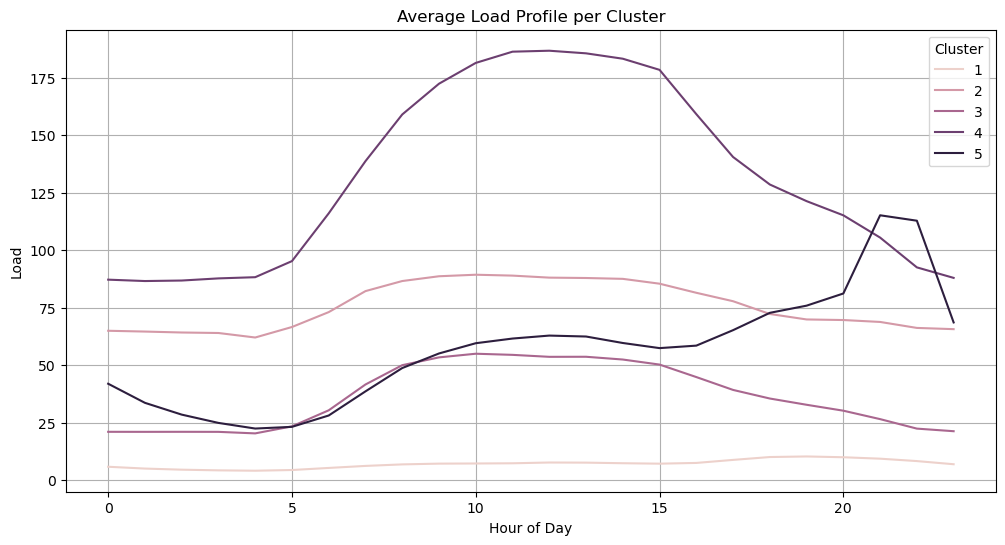

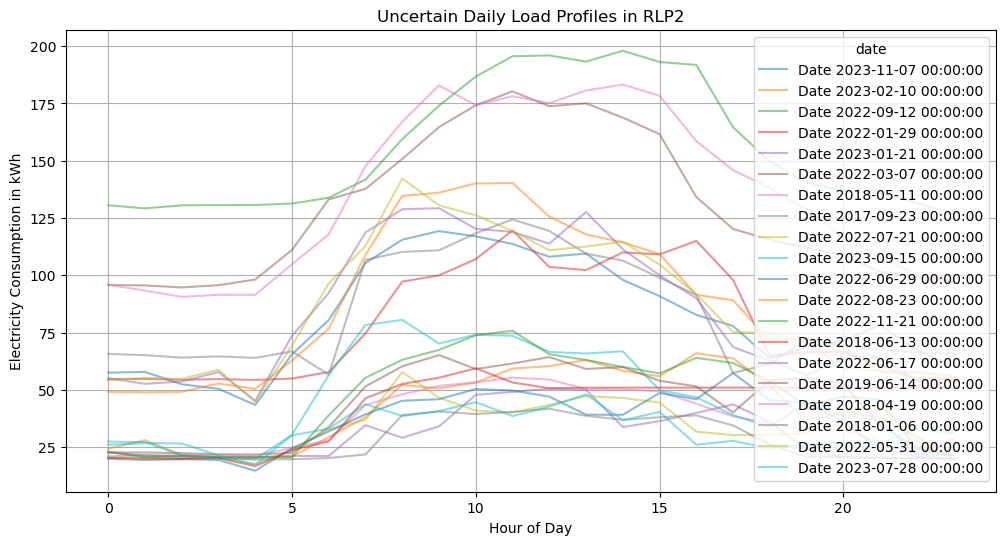

Peak and Minimum Load Profiles:
          Peak_Load  Peak_Hour   Min_Load  Min_Hour
Cluster                                            
1         10.240638         19   4.036058         4
2         89.288771         10  61.980825         4
3         54.925109         10  20.273813         4
4        186.722701         12  86.540234         1
5        115.142633         21  22.382056         4
Confidence Intervals for Average Load Profile:
     Cluster  Hour        mean    CI_Lower    CI_Upper
0          1     0    5.761846    5.693471    5.830220
1          1     1    4.971425    4.915839    5.027011
2          1     2    4.491014    4.442765    4.539263
3          1     3    4.196495    4.152046    4.240944
4          1     4    4.036058    3.993373    4.078742
..       ...   ...         ...         ...         ...
115        5    19   75.834429   73.986910   77.681948
116        5    20   81.126263   79.231902   83.020624
117        5    21  115.142633  112.495950  117.789317
118    

In [28]:
stats, ci_table, u_points = analyze_clusters(df)
df['year'] = pd.to_datetime(df['Date']).dt.year

In [8]:
u_points[['Date','prob_1','prob_2']].value_counts()

Series([], Name: count, dtype: int64)

In [9]:
ci_table['CI_diff'] = ci_table['CI_Upper']-ci_table['CI_Lower']

In [10]:
ci_table[ci_table['Cluster']==1]

,Cluster,Hour,mean,std,count,CI_Lower,CI_Upper,CI_diff
0,1,0,5.761846,1.765048,2560,5.693471,5.830220,0.136749
1,1,1,4.971425,1.434928,2560,4.915839,5.027011,0.111172
2,1,2,4.491014,1.245523,2560,4.442765,4.539263,0.096498
3,1,3,4.196495,1.147423,2560,4.152046,4.240944,0.088898
4,1,4,4.036058,1.101879,2560,3.993373,4.078742,0.085369
5,1,5,4.342622,1.243651,2560,4.294446,4.390798,0.096353
6,1,6,5.247713,1.456590,2560,5.191288,5.304138,0.112850
7,1,7,6.127728,1.868760,2560,6.055337,6.200120,0.144784
8,1,8,6.789108,2.142594,2560,6.706109,6.872108,0.165999
9,1,9,7.122093,2.263628,2560,7.034404,7.209781,0.175376


C:\Users\manya\AppData\Local\Temp\ipykernel_27044\3509880974.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])


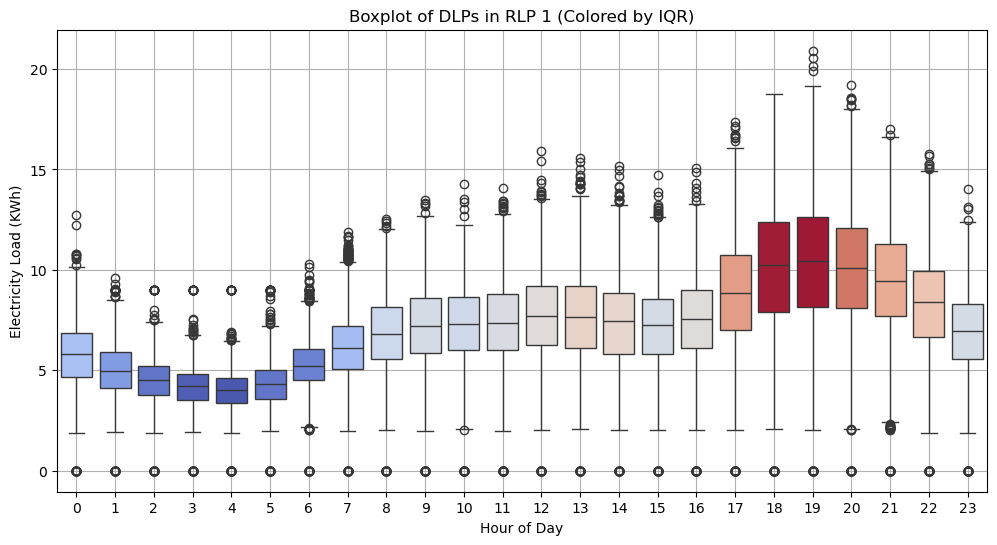

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Select only hourly columns
time_columns = [col for col in df.columns if ':' in col]

# Step 2: Melt the dataframe
df_melted = df1.melt(id_vars=['Date', 'DayOfWeek', 'hour', 'season', 'weekday', 'term_time', 'term_week', 'IsHoliday', 'Cluster', 'prob_1', 'prob_2'],
                    value_vars=time_columns,
                    var_name='Time', value_name='Load')

# Step 3: Convert 'Time' to numerical Hour
df_melted['Hour'] = pd.to_datetime(df_melted['Time'], format='%H:%M:%S').dt.hour

# Step 4: Calculate IQR for each hour
iqr_values = df_melted.groupby('Hour')['Load'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Step 5: Normalize IQR values for color mapping
iqr_scaled = (iqr_values - iqr_values.min()) / (iqr_values.max() - iqr_values.min())

# Step 6: Create a color mapping (higher IQR → darker color, lower IQR → lighter color)
color_palette = sns.color_palette("coolwarm", as_cmap=True)

# Step 7: Plot the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])

# Step 8: Add title and labels
plt.title('Boxplot of DLPs in RLP 1 (Colored by IQR)')
plt.xlabel('Hour of Day')
plt.ylabel('Electricity Load (KWh)')
plt.grid(True)

# Step 9: Show the plot
plt.show()


C:\Users\manya\AppData\Local\Temp\ipykernel_27044\4091521506.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])


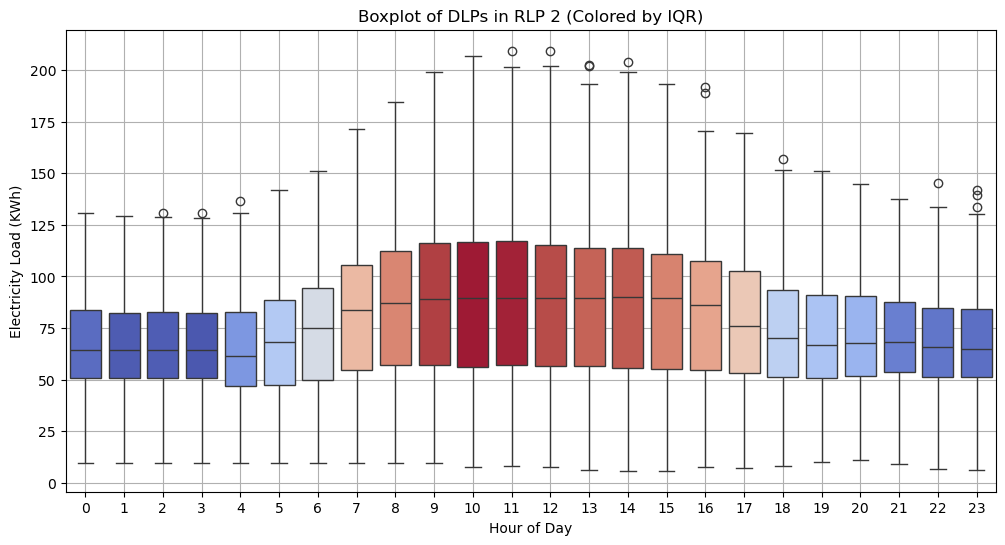

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Select only hourly columns
time_columns = [col for col in df.columns if ':' in col]

# Step 2: Melt the dataframe
df_melted = df2.melt(id_vars=['Date', 'DayOfWeek', 'hour', 'season', 'weekday', 'term_time', 'term_week', 'IsHoliday', 'Cluster', 'prob_1', 'prob_2'],
                    value_vars=time_columns,
                    var_name='Time', value_name='Load')

# Step 3: Convert 'Time' to numerical Hour
df_melted['Hour'] = pd.to_datetime(df_melted['Time'], format='%H:%M:%S').dt.hour

# Step 4: Calculate IQR for each hour
iqr_values = df_melted.groupby('Hour')['Load'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Step 5: Normalize IQR values for color mapping
iqr_scaled = (iqr_values - iqr_values.min()) / (iqr_values.max() - iqr_values.min())

# Step 6: Create a color mapping (higher IQR → darker color, lower IQR → lighter color)
color_palette = sns.color_palette("coolwarm", as_cmap=True)

# Step 7: Plot the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])

# Step 8: Add title and labels
plt.title('Boxplot of DLPs in RLP 2 (Colored by IQR)')
plt.xlabel('Hour of Day')
plt.ylabel('Electricity Load (KWh)')
plt.grid(True)

# Step 9: Show the plot
plt.show()



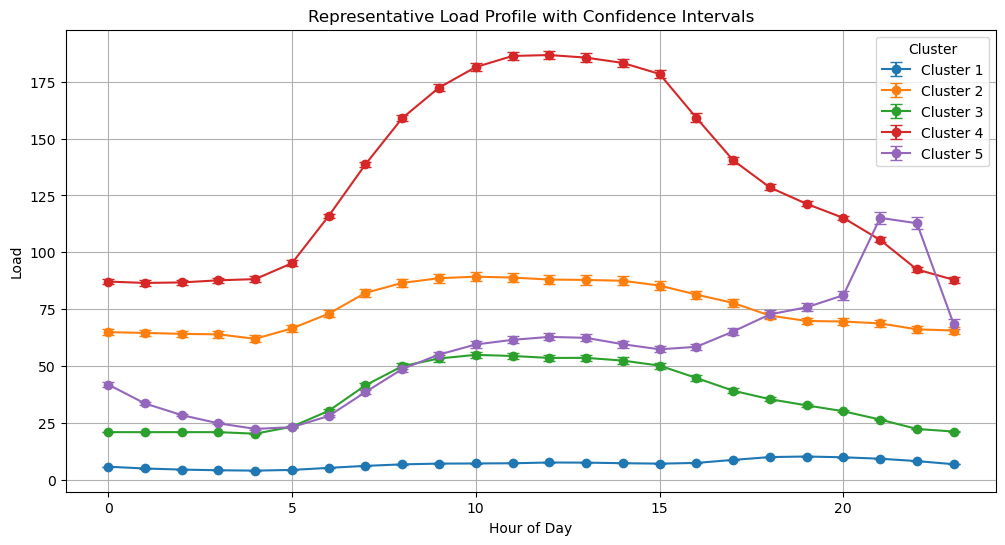

In [31]:
def plot_rlp_with_ci(ci_table):
    plt.figure(figsize=(12, 6))
    
    for cluster in ci_table['Cluster'].unique():
        subset = ci_table[ci_table['Cluster'] == cluster]
        
        # Plot mean values with error bars
        plt.errorbar(
            subset['Hour'], subset['mean'], 
            yerr=[subset['mean'] - subset['CI_Lower'], subset['CI_Upper'] - subset['mean']], 
            fmt='-o', capsize=4, label=f'Cluster {cluster}'
        )
    
    plt.title('Representative Load Profile with Confidence Intervals')
    plt.xlabel('Hour of Day')
    plt.ylabel('Load')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()

    
plot_rlp_with_ci(ci_table)

In [15]:
stats

,Peak_Load,Peak_Hour,Min_Load,Min_Hour
Cluster,,,,
1,10.240638,19,4.036058,4


In [16]:
ci_table[ci_table['Cluster']==2]['std'].mean()

nan

In [17]:
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import numpy as np

def compute_distance_between_clusters(df, cluster1, cluster2, method='euclidean'):
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    
    # Identify hour columns
    hour_columns = df.columns[1:25]
    
    # Melt the DataFrame
    melted_df = df.melt(id_vars=['Date', 'Cluster', 'prob_1', 'prob_2'], value_vars=hour_columns, 
                         var_name='Hour', value_name='Load')
    
    # Convert Hour to int
    melted_df['Hour'] = melted_df['Hour'].str[:2].astype(int)
    
    # Compute average load profiles for both clusters
    avg_load_profile = melted_df.groupby(['Cluster', 'Hour'])['Load'].mean().reset_index()
    
    # Extract load profiles for the specified clusters
    profile1 = avg_load_profile[avg_load_profile['Cluster'] == cluster1]['Load'].values
    profile2 = avg_load_profile[avg_load_profile['Cluster'] == cluster2]['Load'].values
    
    # Convert profiles to 1D NumPy arrays
    profile1 = np.asarray(profile1, dtype=np.float64).flatten()
    profile2 = np.asarray(profile2, dtype=np.float64).flatten()
    
    # Ensure both profiles have the same length
    if len(profile1) != len(profile2):
        raise ValueError("Profiles must have the same number of hourly values")
    
    # Compute distance based on selected method
    if method == 'euclidean':
        distance = euclidean(profile1, profile2)
    elif method == 'dtw':
        distance, _ = fastdtw(profile1, profile2, dist=dtw)
    else:
        raise ValueError("Unsupported distance method. Choose 'euclidean' or 'dtw'.")
    
    return distance


In [18]:
distance_euclidean = compute_distance_between_clusters(df,1,2, method='euclidean')
print(f"Euclidean Distance between 1 and 2: {distance_euclidean}")


Euclidean Distance between 1 and 2: 339.466574879436


In [19]:
filtered_df = df[df['prob_1'].between(0.3, 0.7)]
c1_ambig = filtered_df[filtered_df.Cluster==1]
c1_ambig

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,term_week,IsHoliday,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,building_code,year


In [20]:
c2_ambig = filtered_df[filtered_df.Cluster==2]
c2_ambig

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,term_week,IsHoliday,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,building_code,year
1105,2019-09-04,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,...,1,1,2,0.351,0.649,0.0,0.0,0.0,2,2019


In [21]:
df[df.Cluster==1]['season'].value_counts()
# 1 is winter
# 2 is spring
# 3 is summer
# 4 is autumn

season
4    653
3    649
2    639
1    619
Name: count, dtype: int64

In [22]:
df[df.Cluster==2]['season'].value_counts()

season
3    392
2    315
1    269
4    246
Name: count, dtype: int64

In [32]:
df[df.Cluster==2][['year','season']].value_counts()

year  season
2023  3         98
2018  3         83
2022  3         82
2023  4         74
      2         73
2019  3         68
2022  2         63
2019  2         62
2017  3         61
2018  2         60
      1         60
2019  1         58
2022  4         58
2017  2         57
2022  1         55
2023  1         51
2018  4         46
2017  1         45
2019  4         38
2017  4         30
Name: count, dtype: int64

In [24]:
df[df.Cluster==2][['year','season']].value_counts()

year  season
2023  3         98
2018  3         83
2022  3         82
2023  4         74
      2         73
2019  3         68
2022  2         63
2019  2         62
2017  3         61
2018  2         60
      1         60
2019  1         58
2022  4         58
2017  2         57
2022  1         55
2023  1         51
2018  4         46
2017  1         45
2019  4         38
2017  4         30
Name: count, dtype: int64

In [25]:
df

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,term_week,IsHoliday,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,building_code,year
0,2018-04-23,72.727499,73.547497,72.889999,72.842499,87.289999,104.822498,130.089996,154.797497,176.137497,...,1,1,4,0.0,0.000,0.0,1.000,0.0,1,2018
1,2023-11-07,57.497499,57.827498,52.419999,50.437498,43.400000,65.514999,80.437498,105.334999,115.509998,...,1,1,2,0.0,0.565,0.0,0.435,0.0,1,2023
2,2017-02-21,63.672499,63.087498,61.989998,62.519999,61.857499,61.727500,102.424996,130.017498,156.349995,...,1,1,4,0.0,0.000,0.0,1.000,0.0,1,2017
3,2023-04-08,6.800000,5.632500,4.615000,4.357500,4.232500,5.570000,5.297500,6.282500,6.707500,...,0,0,1,1.0,0.000,0.0,0.000,0.0,2,2023
4,2017-01-31,6.810000,5.600000,4.345000,4.107500,3.815000,3.912500,7.297500,7.282500,8.897500,...,1,1,1,1.0,0.000,0.0,0.000,0.0,3,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7588,2017-03-10,67.169998,68.009998,67.819998,68.554996,67.459999,111.697498,124.027494,148.802498,171.559998,...,1,1,4,0.0,0.000,0.0,1.000,0.0,1,2017
7589,2018-09-27,96.152498,95.444998,118.989992,122.057499,122.124994,135.652496,126.899996,142.817501,156.307499,...,1,1,4,0.0,0.000,0.0,1.000,0.0,6,2018
7590,2022-09-03,4.922500,4.315000,4.170000,4.140000,4.187500,4.187500,4.597500,5.675000,6.880000,...,0,0,1,1.0,0.000,0.0,0.000,0.0,2,2022
7591,2017-09-19,20.360000,20.395000,20.362500,20.175000,20.125000,31.374999,42.412499,56.097499,77.662497,...,1,1,3,0.0,0.000,1.0,0.000,0.0,4,2017


In [26]:
# Convert the 'Date' column to datetime (if not already done)
df['Date'] = pd.to_datetime(df['Date'])

# Extract only the hour columns (assuming all columns up to 'hour' are load values)
hourly_columns = df.columns[1:25]  # Adjust if more or fewer columns represent hourly data

# Compute the mean load profile for each cluster
rlp_df = df.groupby('Cluster')[hourly_columns].mean()

# Ensure the index represents the clusters
rlp_df.index = rlp_df.index.astype(int)

# Display the resulting RLP DataFrame
(rlp_df)


,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
Cluster,,,,,,,,,,,,,,,,,,,,,
1,5.761846,4.971425,4.491014,4.196495,4.036058,4.342622,5.247713,6.127728,6.789108,7.122093,...,7.297557,7.103670,7.425269,8.743315,9.991135,10.240638,9.898200,9.272828,8.226894,6.857320
2,64.910005,64.567447,64.159694,63.941005,61.980825,66.547403,73.028704,82.163332,86.545279,88.624029,...,87.493259,85.387244,81.431567,77.760861,72.213163,69.833860,69.579701,68.748920,66.149731,65.615070
3,20.959056,20.944083,20.961785,20.942312,20.273813,23.333479,30.318037,41.547952,49.943771,53.336224,...,52.400504,50.203774,44.774116,39.179961,35.440024,32.722414,30.143642,26.479759,22.350968,21.222511
4,87.143382,86.540234,86.762317,87.694316,88.215113,95.215417,115.990425,138.697671,158.995404,172.373553,...,183.246570,178.400349,159.134503,140.493552,128.532439,121.295762,115.128565,105.444046,92.484262,87.914592
5,41.873150,33.566868,28.441082,24.833187,22.382056,23.121031,28.061484,38.558939,48.699030,55.039500,...,59.594047,57.366068,58.449059,65.174802,72.711580,75.834429,81.126263,115.142633,112.787248,68.535061


In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import accuracy_score
from scipy.signal import argrelextrema

def extract_rlp_features(rlp_df):
    features = {}
    time_hours = np.arange(len(rlp_df.columns))  # Assuming hourly data
    
    for cluster in rlp_df.index:
        data = rlp_df.loc[cluster].values
        
        # Max and Min Load
        max_load = np.max(data)
        min_load = np.min(data)
        
        # Time of Max and Min Load
        max_time = time_hours[np.argmax(data)]
        min_time = time_hours[np.argmin(data)]
        
        # Local Minima and Maxima
        local_maxima = argrelextrema(data, np.greater)[0]
        local_minima = argrelextrema(data, np.less)[0]
        
        num_local_max = len(local_maxima)
        num_local_min = len(local_minima)
        
        # Time of Local Minima and Maxima
        local_max_times = list(time_hours[local_maxima])
        local_min_times = list(time_hours[local_minima])
        
        # Rate of Change
        rate_of_change = np.diff(data)
        positive_rate = np.mean(rate_of_change[rate_of_change > 0]) if np.any(rate_of_change > 0) else 0
        negative_rate = np.mean(rate_of_change[rate_of_change < 0]) if np.any(rate_of_change < 0) else 0
        overall_gradient = np.mean(rate_of_change)
        
        # Variability & Distribution Features
        std_dev = np.std(data)
        coef_var = std_dev / np.mean(data) if np.mean(data) != 0 else 0
        skewness = pd.Series(data).skew()
        kurtosis = pd.Series(data).kurtosis()
        
        # Peak Load Characteristics
        peak_to_avg_ratio = max_load / np.mean(data) if np.mean(data) != 0 else 0
        load_factor = np.mean(data) / max_load if max_load != 0 else 0
        
        features[cluster] = {
            "max_load": max_load,
            "min_load": min_load,
            "max_time": max_time,
            "min_time": min_time,
            "num_local_max": num_local_max,
            "num_local_min": num_local_min,
            "local_max_times": local_max_times,
            "local_min_times": local_min_times,
            "positive_rate": positive_rate,
            "negative_rate": negative_rate,
            "overall_gradient": overall_gradient,
            "std_dev": std_dev,
            "coef_var": coef_var,
            "skewness": skewness,
            "kurtosis": kurtosis,
            "peak_to_avg_ratio": peak_to_avg_ratio,
            "load_factor": load_factor
        }
    
    return pd.DataFrame(features).T

# Example usage
rlp_features = extract_rlp_features(rlp_df)
rlp_features


,max_load,min_load,max_time,min_time,num_local_max,num_local_min,local_max_times,local_min_times,positive_rate,negative_rate,overall_gradient,std_dev,coef_var,skewness,kurtosis,peak_to_avg_ratio,load_factor
1,10.240638,4.036058,19,4,2,2,"[12, 19]","[4, 15]",0.559077,-0.510314,0.047629,1.804854,0.258206,0.060277,-0.71122,1.465044,0.682573
2,89.288771,61.980825,10,4,1,1,[10],[4],4.551324,-1.564875,0.030655,9.940016,0.131456,0.166042,-1.760078,1.180833,0.84686
3,54.925109,20.273813,10,4,3,3,"[2, 10, 13]","[1, 4, 12]",4.337309,-2.295668,0.011455,13.358266,0.36681,0.149991,-1.724343,1.508213,0.663036
4,186.722701,86.540234,12,1,1,1,[12],[1],9.107497,-8.284271,0.033531,38.452035,0.291143,0.201944,-1.636711,1.413788,0.70732
5,115.142633,22.382056,21,4,2,2,"[12, 21]","[4, 15]",7.015164,-7.950043,1.159214,24.320151,0.429955,0.716225,0.673494,2.0356,0.491256
